In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd "/content/drive/MyDrive/WORK/03-PointNet"

/content/drive/MyDrive/WORK/03-PointNet


In [ ]:
"""
PointNet Model for People Counting (4-Class Classification)
Adapted for 5-dimensional point cloud features (x, y, z, velocity, SNR)
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torch.autograd import Variable

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns


# ====================== Modified STN for 5D input ===========================
class STN5d(nn.Module):
    """Spatial Transformer Network for 5D point features"""
    def __init__(self):
        super(STN5d, self).__init__()
        self.conv1 = torch.nn.Conv1d(5, 64, 1)  # Changed from 3 to 5
        self.conv2 = torch.nn.Conv1d(64, 128, 1)
        self.conv3 = torch.nn.Conv1d(128, 1024, 1)
        self.fc1 = nn.Linear(1024, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 25)  # 5x5 matrix = 25 elements
        self.relu = nn.ReLU()

        self.bn1 = nn.BatchNorm1d(64)
        self.bn2 = nn.BatchNorm1d(128)
        self.bn3 = nn.BatchNorm1d(1024)
        self.bn4 = nn.BatchNorm1d(512)
        self.bn5 = nn.BatchNorm1d(256)

    def forward(self, x):
        batchsize = x.size()[0]
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = torch.max(x, 2, keepdim=True)[0]
        x = x.view(-1, 1024)

        x = F.relu(self.bn4(self.fc1(x)))
        x = F.relu(self.bn5(self.fc2(x)))
        x = self.fc3(x)

        # Identity matrix for 5x5
        iden = Variable(torch.from_numpy(np.eye(5).flatten().astype(np.float32))).view(1, 25).repeat(batchsize, 1)
        if x.is_cuda:
            iden = iden.cuda()
        x = x + iden
        x = x.view(-1, 5, 5)
        return x


class STNkd(nn.Module):
    """Feature transform network"""
    def __init__(self, k=64):
        super(STNkd, self).__init__()
        self.conv1 = torch.nn.Conv1d(k, 64, 1)
        self.conv2 = torch.nn.Conv1d(64, 128, 1)
        self.conv3 = torch.nn.Conv1d(128, 1024, 1)
        self.fc1 = nn.Linear(1024, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, k*k)
        self.relu = nn.ReLU()

        self.bn1 = nn.BatchNorm1d(64)
        self.bn2 = nn.BatchNorm1d(128)
        self.bn3 = nn.BatchNorm1d(1024)
        self.bn4 = nn.BatchNorm1d(512)
        self.bn5 = nn.BatchNorm1d(256)

        self.k = k

    def forward(self, x):
        batchsize = x.size()[0]
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = torch.max(x, 2, keepdim=True)[0]
        x = x.view(-1, 1024)

        x = F.relu(self.bn4(self.fc1(x)))
        x = F.relu(self.bn5(self.fc2(x)))
        x = self.fc3(x)

        iden = Variable(torch.from_numpy(np.eye(self.k).flatten().astype(np.float32))).view(1, self.k*self.k).repeat(batchsize, 1)
        if x.is_cuda:
            iden = iden.cuda()
        x = x + iden
        x = x.view(-1, self.k, self.k)
        return x


class PointNetfeat(nn.Module):
    """Modified PointNet feature extractor for 5D input"""
    def __init__(self, global_feat=True, feature_transform=False):
        super(PointNetfeat, self).__init__()
        self.stn = STN5d()  # Use 5D STN
        self.conv1 = torch.nn.Conv1d(5, 64, 1)  # Changed from 3 to 5
        self.conv2 = torch.nn.Conv1d(64, 128, 1)
        self.conv3 = torch.nn.Conv1d(128, 1024, 1)
        self.bn1 = nn.BatchNorm1d(64)
        self.bn2 = nn.BatchNorm1d(128)
        self.bn3 = nn.BatchNorm1d(1024)
        self.global_feat = global_feat
        self.feature_transform = feature_transform
        if self.feature_transform:
            self.fstn = STNkd(k=64)

    def forward(self, x):
        n_pts = x.size()[2]
        trans = self.stn(x)
        x = x.transpose(2, 1)
        x = torch.bmm(x, trans)
        x = x.transpose(2, 1)
        x = F.relu(self.bn1(self.conv1(x)))

        if self.feature_transform:
            trans_feat = self.fstn(x)
            x = x.transpose(2, 1)
            x = torch.bmm(x, trans_feat)
            x = x.transpose(2, 1)
        else:
            trans_feat = None

        pointfeat = x
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.bn3(self.conv3(x))
        x = torch.max(x, 2, keepdim=True)[0]
        x = x.view(-1, 1024)
        if self.global_feat:
            return x, trans, trans_feat
        else:
            x = x.view(-1, 1024, 1).repeat(1, 1, n_pts)
            return torch.cat([x, pointfeat], 1), trans, trans_feat


class PeopleCountingPointNet(nn.Module):
    """PointNet for 4-class people counting"""
    def __init__(self, num_classes=4, feature_transform=False):
        super(PeopleCountingPointNet, self).__init__()
        self.feature_transform = feature_transform
        self.feat = PointNetfeat(global_feat=True, feature_transform=feature_transform)
        self.fc1 = nn.Linear(1024, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, num_classes)
        self.dropout = nn.Dropout(p=0.3)
        self.bn1 = nn.BatchNorm1d(512)
        self.bn2 = nn.BatchNorm1d(256)
        self.relu = nn.ReLU()

    def forward(self, x):
        # x shape: (batch_size, 128, 5)
        # Need to transpose to (batch_size, 5, 128) for Conv1d
        x = x.transpose(1, 2)

        x, trans, trans_feat = self.feat(x)
        x = F.relu(self.bn1(self.fc1(x)))
        x = F.relu(self.bn2(self.dropout(self.fc2(x))))
        x = self.fc3(x)
        # Return logits directly without log_softmax for CrossEntropyLoss
        return x


def feature_transform_regularizer(trans):
    """Regularization loss for transform matrix"""
    d = trans.size()[1]
    batchsize = trans.size()[0]
    I = torch.eye(d)[None, :, :]
    if trans.is_cuda:
        I = I.cuda()
    loss = torch.mean(torch.norm(torch.bmm(trans, trans.transpose(2, 1)) - I, dim=(1, 2)))
    return loss


# ====================== Dataset Class ===========================
class RadarPointCloudDataset(Dataset):
    def __init__(self, data_path, labels_path):
        self.data = np.load(data_path).astype(np.float32)
        self.labels = np.load(labels_path).astype(np.int64)

        # Assuming data shape is (N, 128, 5) where 128 is points and 5 is features
        print(f"Data shape: {self.data.shape}")
        print(f"Labels shape: {self.labels.shape}")
        print(f"Number of classes: {len(np.unique(self.labels))}")
        print(f"Class distribution: {np.bincount(self.labels)}")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        x = self.data[idx]    # (128, 5)
        y = self.labels[idx]  # scalar label
        return torch.from_numpy(x), torch.tensor(y)


# ====================== Train + Eval Functions ===========================
def train_epoch(model, loader, criterion, optimizer, device, use_feature_transform=False):
    """Train for one epoch with optional transform regularization"""
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()

        logits = model(x)
        loss = criterion(logits, y)

        # Add transform regularization if using feature transform
        if use_feature_transform:
            # Get the transform matrices through a forward pass
            x_trans = x.transpose(1, 2)
            _, trans, trans_feat = model.feat(x_trans)

            # Add regularization loss
            if trans_feat is not None:
                loss += 0.001 * feature_transform_regularizer(trans_feat)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # Calculate accuracy
        _, predicted = torch.max(logits.data, 1)
        total += y.size(0)
        correct += (predicted == y).sum().item()

    return total_loss / len(loader), 100 * correct / total


def evaluate(model, loader, device):
    """Evaluate model performance"""
    model.eval()
    preds_list = []
    labels_list = []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            preds = torch.argmax(logits, dim=1)
            preds_list.append(preds.cpu())
            labels_list.append(y.cpu())

    preds = torch.cat(preds_list).numpy()
    labels = torch.cat(labels_list).numpy()

    acc = accuracy_score(labels, preds)
    prec = precision_score(labels, preds, average='macro', zero_division=0)
    rec = recall_score(labels, preds, average='macro', zero_division=0)
    f1 = f1_score(labels, preds, average='macro', zero_division=0)

    return acc, prec, rec, f1, labels, preds


# ====================== Main ===========================
if __name__ == "__main__":

    # Hyperparameters
    BATCH_SIZE = 32
    LEARNING_RATE = 1e-3
    NUM_EPOCHS = 50
    USE_FEATURE_TRANSFORM = True  # Enable feature transform for better performance

    # Load dataset
    print("Loading dataset...")
    train_dataset = RadarPointCloudDataset(
        "processed_dataset_8FPS/radar_data_train.npy",
        "processed_dataset_8FPS/radar_labels_train.npy"
    )
    test_dataset = RadarPointCloudDataset(
        "processed_dataset_8FPS/radar_data_test.npy",
        "processed_dataset_8FPS/radar_labels_test.npy"
    )

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    # Initialize model
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    model = PeopleCountingPointNet(num_classes=4, feature_transform=USE_FEATURE_TRANSFORM).to(device)

    # Print model architecture
    print(f"\nModel architecture:")
    print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
    print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

    # Loss and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, betas=(0.9, 0.999))
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

    # Training history
    train_acc_history = []
    test_acc_history = []
    train_loss_history = []

    best_test_acc = 0

    # -------------------- Training Loop --------------------
    print("\nStarting training...")
    for epoch in range(NUM_EPOCHS):
        # Train
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device, USE_FEATURE_TRANSFORM)
        train_loss_history.append(train_loss)

        # Evaluate
        train_acc_eval, _, _, _, _, _ = evaluate(model, train_loader, device)
        test_acc, test_prec, test_rec, test_f1, _, _ = evaluate(model, test_loader, device)

        train_acc_history.append(train_acc_eval)
        test_acc_history.append(test_acc)

        # Save best model
        if test_acc > best_test_acc:
            best_test_acc = test_acc
            torch.save(model.state_dict(), "best_people_count_pointnet.pth")

        # Print progress
        print(f"Epoch {epoch+1:03d}/{NUM_EPOCHS} | "
              f"Train Loss: {train_loss:.4f} | "
              f"Train Acc: {train_acc_eval*100:.2f}% | "
              f"Test Acc: {test_acc*100:.2f}% | "
              f"Test F1: {test_f1*100:.2f}% | "
              f"LR: {scheduler.get_last_lr()[0]:.6f}")

        scheduler.step()

    # -------------------- Final Evaluation --------------------
    print("\n" + "="*50)
    print("Loading best model for final evaluation...")
    model.load_state_dict(torch.load("best_people_count_pointnet.pth"))

    acc, prec, rec, f1, y_true, y_pred = evaluate(model, test_loader, device)

    print("\n===== Final Test Evaluation =====")
    print(f"Accuracy : {acc*100:.2f}%")
    print(f"Precision: {prec*100:.2f}%")
    print(f"Recall   : {rec*100:.2f}%")
    print(f"F1-score : {f1*100:.2f}%")
    print(f"Best Test Accuracy: {best_test_acc*100:.2f}%")

    # Per-class metrics
    from sklearn.metrics import classification_report
    print("\nPer-class metrics:")
    print(classification_report(y_true, y_pred, target_names=['0 people', '1 person', '2 people', '3 people']))

    # -------------------- Visualization --------------------
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=['0', '1', '2', '3'],
                yticklabels=['0', '1', '2', '3'])
    plt.xlabel("Predicted Number of People")
    plt.ylabel("True Number of People")
    plt.title("Confusion Matrix - PointNet People Counting")
    plt.tight_layout()
    plt.savefig("confusion_matrix_pointnet.png", dpi=150)
    plt.show()

    # Training curves
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy curve
    ax1.plot(train_acc_history, label="Train Accuracy", linewidth=2)
    ax1.plot(test_acc_history, label="Test Accuracy", linewidth=2)
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Accuracy")
    ax1.set_title("Train vs Test Accuracy")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Loss curve
    ax2.plot(train_loss_history, label="Train Loss", linewidth=2, color='red')
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Loss")
    ax2.set_title("Training Loss")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("training_curves_pointnet.png", dpi=150)
    plt.show()

    # Save final model
    torch.save(model.state_dict(), "final_people_count_pointnet.pth")
    print(f"\nModels saved:")
    print("  - best_people_count_pointnet.pth (Best test accuracy: {:.2f}%)".format(best_test_acc*100))
    print("  - final_people_count_pointnet.pth (Last epoch model)")

Loading dataset...
Data shape: (11497, 1024, 5)
Labels shape: (11497,)
Number of classes: 3
Class distribution: [   0 3829 3830 3838]
Data shape: (2870, 1024, 5)
Labels shape: (2870,)
Number of classes: 3
Class distribution: [  0 955 957 958]
Using device: cuda

Model architecture:
Total parameters: 3,466,589
Trainable parameters: 3,466,589

Starting training...
Epoch 001/50 | Train Loss: 0.8566 | Train Acc: 74.11% | Test Acc: 72.20% | Test F1: 72.80% | LR: 0.001000
Epoch 002/50 | Train Loss: 0.6090 | Train Acc: 39.56% | Test Acc: 39.90% | Test F1: 31.85% | LR: 0.001000
Epoch 003/50 | Train Loss: 0.5264 | Train Acc: 83.33% | Test Acc: 80.49% | Test F1: 80.41% | LR: 0.001000
Epoch 004/50 | Train Loss: 0.4656 | Train Acc: 82.99% | Test Acc: 80.70% | Test F1: 80.34% | LR: 0.001000
Epoch 005/50 | Train Loss: 0.4412 | Train Acc: 87.39% | Test Acc: 84.25% | Test F1: 84.24% | LR: 0.001000
Epoch 006/50 | Train Loss: 0.3894 | Train Acc: 88.34% | Test Acc: 84.22% | Test F1: 84.24% | LR: 0.001000

ValueError: Number of classes, 3, does not match size of target_names, 4. Try specifying the labels parameter


Per-class metrics:
              precision    recall  f1-score   support

    1 person       0.96      1.00      0.98       955
    2 people       0.88      0.83      0.86       957
    3 people       0.87      0.88      0.88       958

    accuracy                           0.90      2870
   macro avg       0.90      0.90      0.90      2870
weighted avg       0.90      0.90      0.90      2870



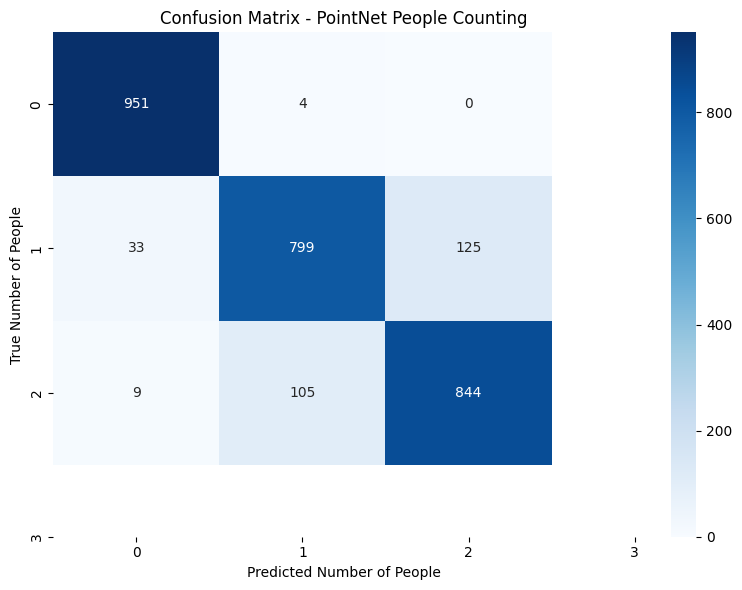

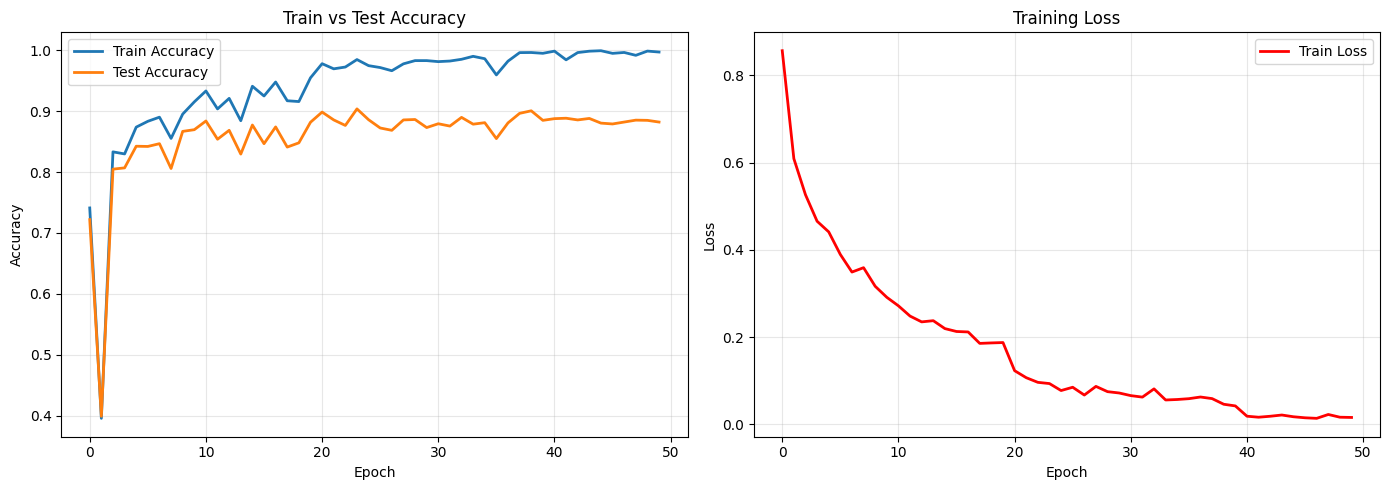


Models saved:
  - best_people_count_pointnet.pth (Best test accuracy: 90.38%)
  - final_people_count_pointnet.pth (Last epoch model)


In [ ]:
# Per-class metrics
from sklearn.metrics import classification_report
print("\nPer-class metrics:")
print(classification_report(y_true, y_pred, target_names=['1 person', '2 people', '3 people']))

# -------------------- Visualization --------------------
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
          xticklabels=['0', '1', '2', '3'],
          yticklabels=['0', '1', '2', '3'])
plt.xlabel("Predicted Number of People")
plt.ylabel("True Number of People")
plt.title("Confusion Matrix - PointNet People Counting")
plt.tight_layout()
plt.savefig("confusion_matrix_pointnet.png", dpi=150)
plt.show()

# Training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy curve
ax1.plot(train_acc_history, label="Train Accuracy", linewidth=2)
ax1.plot(test_acc_history, label="Test Accuracy", linewidth=2)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.set_title("Train vs Test Accuracy")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss curve
ax2.plot(train_loss_history, label="Train Loss", linewidth=2, color='red')
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.set_title("Training Loss")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves_pointnet.png", dpi=150)
plt.show()

# Save final model
torch.save(model.state_dict(), "final_people_count_pointnet.pth")
print(f"\nModels saved:")
print("  - best_people_count_pointnet.pth (Best test accuracy: {:.2f}%)".format(best_test_acc*100))
print("  - final_people_count_pointnet.pth (Last epoch model)")